# Dataset Info

The payments table contains 100K entries. For this notebook, 2K entries where selected. In order to not have bias inside data, we specifically selected 33% of the payments as being from the Downtown store, 33% from the Suburban store, and 33% from the Online store.

## Data Selection

The queries that we run are the following:

```
SELECT * FROM store.payments WHERE channel = 'Physical - Downtown' LIMIT 0,666 ORDER BY RANDOM()
UNION
SELECT * FROM store.payments WHERE channel = 'Physical - Suburban' LIMIT 0,667 ORDER BY RANDOM()
UNION
SELECT * FROM store.payments WHERE channel = 'Online' LIMIT 0,667 ORDER BY RANDOM()
```

In [103]:
%pip install mysql-connector-python

You should consider upgrading via the '/Users/gabigutu/05Work/Teach/Link_Academy/2025-2026/Python/26_07-LA-Py-Data_Analysis/code/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
from _connection import connection

In [107]:
my_cursor = connection.cursor(dictionary=True)

In [108]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Physical - Downtown' ORDER BY RAND() LIMIT 0,666")
downtown_payments = my_cursor.fetchall()
downtown_payments

[{'transaction_id': 'TXN-1050956',
  'timestamp': datetime.datetime(2025, 9, 8, 17, 38, 20),
  'customer_id': 'GUEST',
  'channel': 'Physical - Downtown',
  'product_category': 'Home & Kitchen',
  'amount': Decimal('30.24'),
  'payment_method': 'Credit Card',
  'status': 'Refunded'},
 {'transaction_id': 'TXN-1029138',
  'timestamp': datetime.datetime(2025, 4, 2, 14, 29, 17),
  'customer_id': 'GUEST',
  'channel': 'Physical - Downtown',
  'product_category': 'Home & Kitchen',
  'amount': Decimal('76.98'),
  'payment_method': 'Debit Card',
  'status': 'Completed'},
 {'transaction_id': 'TXN-1046329',
  'timestamp': datetime.datetime(2025, 8, 6, 3, 56),
  'customer_id': 'GUEST',
  'channel': 'Physical - Downtown',
  'product_category': 'Electronics',
  'amount': Decimal('911.85'),
  'payment_method': 'Credit Card',
  'status': 'Completed'},
 {'transaction_id': 'TXN-1072724',
  'timestamp': datetime.datetime(2026, 2, 14, 5, 17, 36),
  'customer_id': 'CUST-18891',
  'channel': 'Physical - Do

In [109]:
df_downtown = pd.DataFrame(downtown_payments)
df_downtown

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1050956,2025-09-08 17:38:20,GUEST,Physical - Downtown,Home & Kitchen,30.24,Credit Card,Refunded
1,TXN-1029138,2025-04-02 14:29:17,GUEST,Physical - Downtown,Home & Kitchen,76.98,Debit Card,Completed
2,TXN-1046329,2025-08-06 03:56:00,GUEST,Physical - Downtown,Electronics,911.85,Credit Card,Completed
3,TXN-1072724,2026-02-14 05:17:36,CUST-18891,Physical - Downtown,Clothing,64.71,Debit Card,Completed
4,TXN-1096174,2026-08-04 12:38:26,GUEST,Physical - Downtown,Clothing,44.80,Debit Card,Completed
...,...,...,...,...,...,...,...,...
661,TXN-1005574,2024-10-12 06:27:53,CUST-22496,Physical - Downtown,Clothing,43.01,Apple Pay,Completed
662,TXN-1002485,2024-09-19 20:46:31,CUST-16519,Physical - Downtown,Books & Stationery,19.32,Debit Card,Completed
663,TXN-1063882,2025-12-12 05:12:06,CUST-14029,Physical - Downtown,Clothing,41.31,Credit Card,Completed
664,TXN-1074829,2026-03-01 02:14:44,GUEST,Physical - Downtown,Beauty & Personal Care,32.20,Debit Card,Completed


In [110]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Physical - Suburban' ORDER BY RAND() LIMIT 0,667")
df_suburban = pd.DataFrame(my_cursor.fetchall())
df_suburban

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1067816,2026-01-09 14:49:35,CUST-10697,Physical - Suburban,Beauty & Personal Care,22.60,Debit Card,Completed
1,TXN-1023358,2025-02-18 06:36:38,CUST-10067,Physical - Suburban,Electronics,119.54,Debit Card,Completed
2,TXN-1079090,2026-04-01 21:36:00,CUST-18421,Physical - Suburban,Clothing,56.18,Credit Card,Completed
3,TXN-1066299,2025-12-29 14:13:54,CUST-18273,Physical - Suburban,Clothing,10.67,Credit Card,Completed
4,TXN-1082604,2026-04-27 13:07:28,CUST-21758,Physical - Suburban,Clothing,28.14,Debit Card,Completed
...,...,...,...,...,...,...,...,...
662,TXN-1091383,2026-06-30 01:04:20,GUEST,Physical - Suburban,Electronics,71.42,Credit Card,Completed
663,TXN-1029128,2025-04-02 11:20:55,CUST-16610,Physical - Suburban,Beauty & Personal Care,26.98,Debit Card,Completed
664,TXN-1090286,2026-06-21 17:27:16,GUEST,Physical - Suburban,Home & Kitchen,113.24,Cash,Completed
665,TXN-1098762,2026-08-22 17:58:39,CUST-19031,Physical - Suburban,Beauty & Personal Care,88.34,Apple Pay,Completed


In [111]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Online' ORDER BY RAND() LIMIT 0,667")
df_online = pd.DataFrame(my_cursor.fetchall())
df_online

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1097343,2026-08-12 15:19:35,CUST-13566,Online,Home & Kitchen,122.73,Credit Card,Completed
1,TXN-1030774,2025-04-15 02:55:33,CUST-23738,Online,Home & Kitchen,167.26,Debit Card,Completed
2,TXN-1018996,2025-01-17 16:37:29,CUST-24724,Online,Home & Kitchen,54.17,Apple Pay,Completed
3,TXN-1092708,2026-07-09 17:20:37,CUST-15885,Online,Electronics,83.58,Credit Card,Completed
4,TXN-1074601,2026-02-27 15:07:42,CUST-15425,Online,Electronics,40.38,Apple Pay,Completed
...,...,...,...,...,...,...,...,...
662,TXN-1000347,2024-09-03 21:03:59,GUEST,Online,Beauty & Personal Care,19.31,Credit Card,Failed
663,TXN-1063667,2025-12-10 14:52:19,CUST-14325,Online,Electronics,54.08,PayPal,Completed
664,TXN-1073824,2026-02-22 07:51:55,GUEST,Online,Home & Kitchen,71.25,PayPal,Completed
665,TXN-1079011,2026-04-01 05:46:54,CUST-23755,Online,Beauty & Personal Care,14.99,Debit Card,Completed


In [112]:
df_2k = pd.concat([df_downtown, df_suburban, df_online], ignore_index=True)
df_2k

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1050956,2025-09-08 17:38:20,GUEST,Physical - Downtown,Home & Kitchen,30.24,Credit Card,Refunded
1,TXN-1029138,2025-04-02 14:29:17,GUEST,Physical - Downtown,Home & Kitchen,76.98,Debit Card,Completed
2,TXN-1046329,2025-08-06 03:56:00,GUEST,Physical - Downtown,Electronics,911.85,Credit Card,Completed
3,TXN-1072724,2026-02-14 05:17:36,CUST-18891,Physical - Downtown,Clothing,64.71,Debit Card,Completed
4,TXN-1096174,2026-08-04 12:38:26,GUEST,Physical - Downtown,Clothing,44.80,Debit Card,Completed
...,...,...,...,...,...,...,...,...
1995,TXN-1000347,2024-09-03 21:03:59,GUEST,Online,Beauty & Personal Care,19.31,Credit Card,Failed
1996,TXN-1063667,2025-12-10 14:52:19,CUST-14325,Online,Electronics,54.08,PayPal,Completed
1997,TXN-1073824,2026-02-22 07:51:55,GUEST,Online,Home & Kitchen,71.25,PayPal,Completed
1998,TXN-1079011,2026-04-01 05:46:54,CUST-23755,Online,Beauty & Personal Care,14.99,Debit Card,Completed


In [113]:
df_2k['amount'].max()

Decimal('988.86')

(array([1900.,   75.,   19.,    3.,    3.]),
 array([  7.84 , 204.044, 400.248, 596.452, 792.656, 988.86 ]),
 <BarContainer object of 5 artists>)

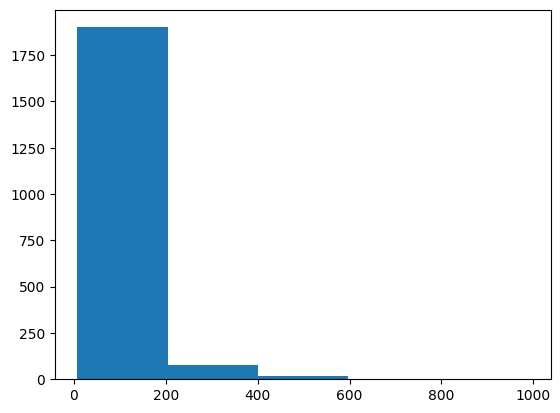

In [114]:
plt.hist(list(df_2k['amount']), bins=5)

In [115]:
df_2k_cheap = df_2k [ df_2k['amount'].between(0, 213.6) ] 
df_2k_cheap

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1050956,2025-09-08 17:38:20,GUEST,Physical - Downtown,Home & Kitchen,30.24,Credit Card,Refunded
1,TXN-1029138,2025-04-02 14:29:17,GUEST,Physical - Downtown,Home & Kitchen,76.98,Debit Card,Completed
3,TXN-1072724,2026-02-14 05:17:36,CUST-18891,Physical - Downtown,Clothing,64.71,Debit Card,Completed
4,TXN-1096174,2026-08-04 12:38:26,GUEST,Physical - Downtown,Clothing,44.80,Debit Card,Completed
5,TXN-1039498,2025-06-16 20:04:11,CUST-11132,Physical - Downtown,Beauty & Personal Care,37.11,Debit Card,Completed
...,...,...,...,...,...,...,...,...
1995,TXN-1000347,2024-09-03 21:03:59,GUEST,Online,Beauty & Personal Care,19.31,Credit Card,Failed
1996,TXN-1063667,2025-12-10 14:52:19,CUST-14325,Online,Electronics,54.08,PayPal,Completed
1997,TXN-1073824,2026-02-22 07:51:55,GUEST,Online,Home & Kitchen,71.25,PayPal,Completed
1998,TXN-1079011,2026-04-01 05:46:54,CUST-23755,Online,Beauty & Personal Care,14.99,Debit Card,Completed


(array([231., 380., 336., 272., 187., 132.,  87.,  74.,  52.,  43.,  34.,
         30.,  19.,  20.,   7.]),
 array([  7.84      ,  21.55666667,  35.27333333,  48.99      ,
         62.70666667,  76.42333333,  90.14      , 103.85666667,
        117.57333333, 131.29      , 145.00666667, 158.72333333,
        172.44      , 186.15666667, 199.87333333, 213.59      ]),
 <BarContainer object of 15 artists>)

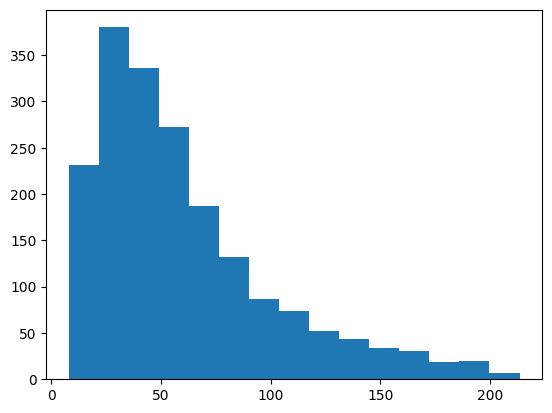

In [116]:
plt.hist(list(df_2k_cheap['amount']), bins=15)

In [117]:
# df = pd.read_csv('data/payments_2k.csv')

(array([3588., 9638., 8918., 6768., 4853., 3489., 2560., 1859., 1420.,
        1081.,  818.,  662.,  532.,  479.,  374.]),
 array([  4.11 ,  18.068,  32.026,  45.984,  59.942,  73.9  ,  87.858,
        101.816, 115.774, 129.732, 143.69 , 157.648, 171.606, 185.564,
        199.522, 213.48 ]),
 <BarContainer object of 15 artists>)

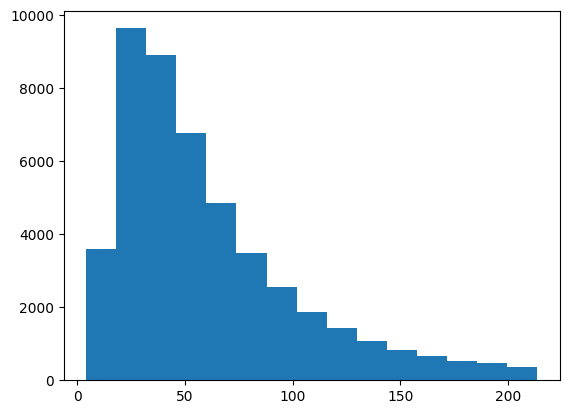

In [120]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Online'")
df_online_all = pd.DataFrame(my_cursor.fetchall())
df_online_all_cheap = df_online_all [ df_online_all['amount'].between(0, 213.6) ] 
plt.hist(list(df_online_all_cheap['amount']), bins=15)

In [127]:
df_2k_amount = df_2k[ ['channel', 'amount'] ]
channel_sum = df_2k_amount.groupby('channel').sum()
channel_sum

,amount
channel,
Online,49286.92
Physical - Downtown,53390.46
Physical - Suburban,46978.69


In [130]:
list(channel_sum.index)

['Online', 'Physical - Downtown', 'Physical - Suburban']

In [132]:
list(channel_sum['amount'])

[Decimal('49286.92'), Decimal('53390.46'), Decimal('46978.69')]

<BarContainer object of 3 artists>

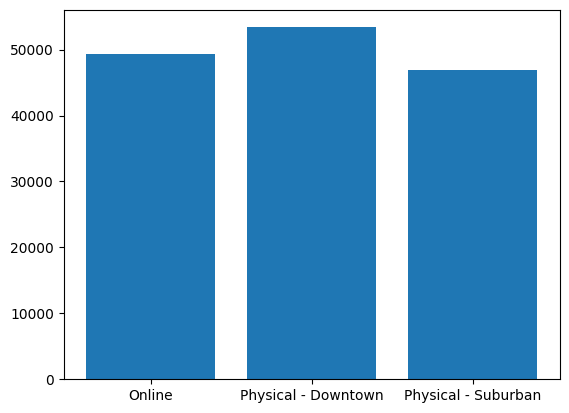

In [133]:
plt.bar(channel_sum.index, channel_sum['amount'])